In [28]:
import os
import shutil
import json
import re
import matplotlib.pyplot as plt
from struct_eval_functions import *
from struct_plot_funcitons import *

### JSON to Text

In [29]:
def process_node(node):
    if 'raw_text' in node:
        return node['raw_text'].strip()
    if 'AND' in node:
        left_text = process_node(node['AND']['left'])
        right_text = process_node(node['AND']['right'])
        return combine_texts(left_text, right_text, '[AND]')
    if 'OR' in node:
        left_text = process_node(node['OR']['left'])
        right_text = process_node(node['OR']['right'])
        return combine_texts(left_text, right_text, '[OR]')
    if 'NOT' in node:
        left_text = process_node(node['NOT']['left'])
        return f"[NOT] {left_text}"

    return ""

def combine_texts(left_text, right_text, operator):
    ### Hier muss es bearbeitet werden Entweder lösche AND am ENDE oder nicht
    #if operator == '[AND]' and (left_text.strip().endswith('.') or right_text.strip().startswith('-')):
    #    return f"{left_text}\n{right_text}"
    combined = f"{left_text.strip()} {operator} {right_text.strip()}"
    if operator == '[AND]' and not right_text.strip():
        return combined + '\n'
    return combined


def json_to_text(json_file_path):
    with open(json_file_path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    text = process_node(data)
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    return '\n'.join(lines)

def process_all_files_in_directory(directory_path, output_directory, failure_directory):
    os.makedirs(output_directory, exist_ok=True)
    os.makedirs(failure_directory, exist_ok=True)
    for filename in os.listdir(directory_path):
        if filename.endswith("_exc.json") or filename.endswith("_inc.json"):
            json_file_path = os.path.join(directory_path, filename)
            try:
                output_text = json_to_text(json_file_path)
                output_file_path = os.path.join(output_directory, os.path.splitext(filename)[0] + ".txt")
                with open(output_file_path, 'w', encoding="utf-8") as output_file:
                    output_file.write(output_text)
            except Exception as e:
                print(f"Failed to process file: {filename} - Error: {e}")
                shutil.move(json_file_path, os.path.join(failure_directory, filename))
                print(os.path.join(failure_directory, filename))

In [30]:
models_path = 'eval_p2/model_output'
models = get_models(models_path)
models = [models[1]]
models

['Llama-3-70B-Instruct_3_shot_prompt2']

In [31]:
batch_path = "eval_p2"
label_folder = "../input/lct_p3"

#### Filter failure model files

In [32]:
for model_name in models:
    model_folder = f"{batch_path}/model_output/{model_name}/output"
    ready_folder = f"{batch_path}/model_output/{model_name}/ready"
    failure_folder = f"{batch_path}/model_output/{model_name}/failure"
    process_failure_folder = f"{batch_path}/model_output/{model_name}/processed_output"

    ## Filter Failure Files
    read_and_process_files(model_path="eval_p2/model_output" ,model_name=model_name)

    ## JSON to Text
    process_all_files_in_directory(ready_folder, process_failure_folder, failure_folder)

Failed to process file: Llama-3-70B-Instruct_NCT03860220_inc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03860324_exc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03860402_exc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03860688_exc.json - Error: 'right'
JSON syntax error in file: Llama-3-70B-Instruct_NCT03861078_inc.json - Error: Extra data: line 2 column 1 (char 3)
Failed to process file: Llama-3-70B-Instruct_NCT03861104_exc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03861507_inc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03861715_inc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03862209_inc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03862287_exc.json - Error: 'right'
Failed to process file: Llama-3-70B-Instruct_NCT03862456_inc.json - Error: 'right'
JSON syntax error in file: Llama-3-70B-Instruct_NCT0386

In [33]:
# metrics = process_files(label_folder, ready_folder)
# print("Metrics:")
# for category, scores in metrics.items():
#     print(f"{category}:")
#     print(f"  Precision: {scores['precision']:.4f}")
#     print(f"  Recall: {scores['recall']:.4f}")
#     print(f"  F1-score: {scores['f1']:.4f}")
#     print(f"  Accuracy: {scores['accuracy']:.4f}")

#### Anzahl der Fehler in der Modelausgabe

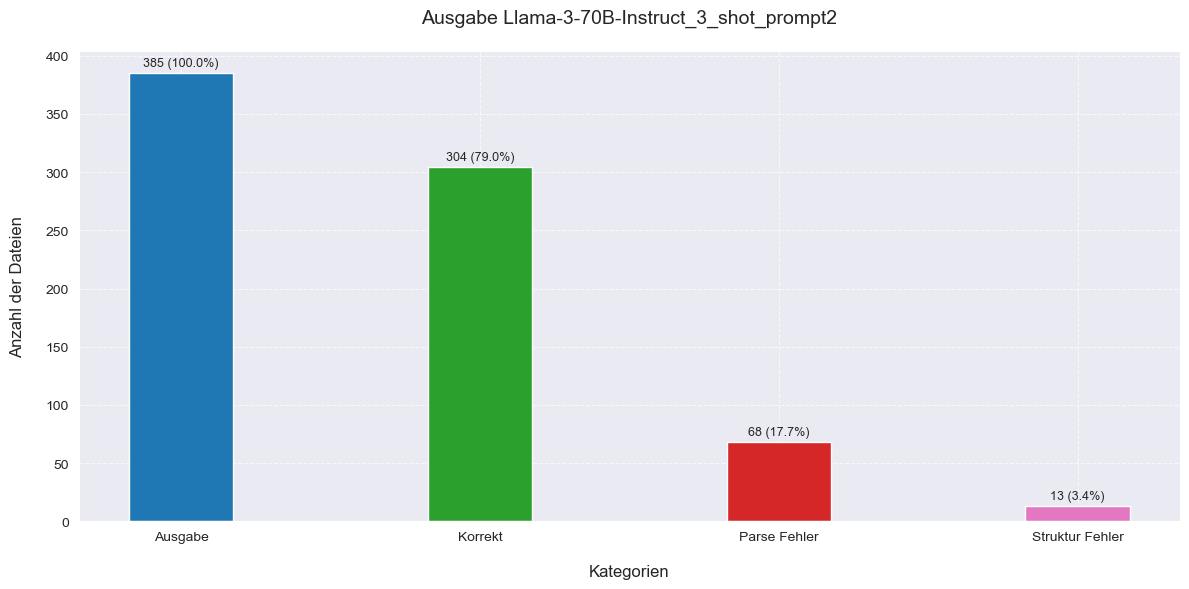

In [34]:
plot_file_counts(model_name, batch_name="eval_p2")

In [35]:
def latex_file_counts_table(model_name, batch_name):
    model_folder_count, ready_folder_count, failure_folder_count, struct_failure_folder_count = count_files(model_name, batch_name)
    total_files = model_folder_count

    latex_table = f"""
\\begin{{table}}[ht]
\\centering
\\begin{{tabular}}{{lrr}}
\\toprule
\\textbf{{Kategorie}} & \\textbf{{Anzahl}} & \\textbf{{Prozent}} \\\\
\\midrule
Ausgabe & {model_folder_count} & 100.0\\% \\\\
Korrekt & {ready_folder_count} & {(ready_folder_count / total_files * 100):.1f}\\% \\\\
Parse Fehler & {failure_folder_count} & {(failure_folder_count / total_files * 100):.1f}\\% \\\\
Struktur Fehler & {struct_failure_folder_count} & {(struct_failure_folder_count / total_files * 100):.1f}\\% \\\\
\\bottomrule
\\end{{tabular}}
\\caption{{Ausgabe {model_name}}}
\\label{{tab:file_counts_{model_name.replace(" ", "_")}}}
\\end{{table}}
    """

    return latex_table

# Beispielaufruf:
print(latex_file_counts_table(model_name, batch_name=batch_path))


\begin{table}[ht]
\centering
\begin{tabular}{lrr}
\toprule
\textbf{Kategorie} & \textbf{Anzahl} & \textbf{Prozent} \\
\midrule
Ausgabe & 385 & 100.0\% \\
Korrekt & 304 & 79.0\% \\
Parse Fehler & 68 & 17.7\% \\
Struktur Fehler & 13 & 3.4\% \\
\bottomrule
\end{tabular}
\caption{Ausgabe Llama-3-70B-Instruct_3_shot_prompt2}
\label{tab:file_counts_Llama-3-70B-Instruct_3_shot_prompt2}
\end{table}
    


#### Model Performance

In [36]:
label_folder = "../input/lct_p1_half_with_and/" # '../input/lct_p1_half/'
raw_lct_text_folder = '../input/lct_txt_half'
model_output_folder = f'{batch_path}/model_output/'

In [37]:
def extract_file_name(filename):
    pattern = r'NCT(\d+)_(inc|exc)'
    match = re.search(pattern, filename)
    if match:
        nct_number = 'NCT' + match.group(1)
        suffix = match.group(2)
        return f"{nct_number}_{suffix}"
    else:
        return None

def find_operator_words(text, operators):
    words = {op: [] for op in operators}
    word_list = text.split()
    for i, word in enumerate(word_list):
        if word in ["[AND]", "[OR]", "[NOT]", "[AND1]"]:
            operator = word[1:-1]
            if operator in operators:
                j = i - 1
                while j >= 0 and word_list[j] in ["[AND]", "[OR]", "[NOT]", "[AND1]"]:
                    j -= 1
                if j >= 0:
                    prev_word = re.sub(r'[^\w]', '', word_list[j])  # Remove punctuation
                    words[operator].append(prev_word)
    return words

def compare_operators(label_text, model_text, operator):
    label_operators = extract_operators(label_text) + ['AND1']
    model_operators = extract_operators(model_text)

    label_words_dict = find_operator_words(label_text, label_operators)
    model_words_dict = find_operator_words(model_text, model_operators)

    tp = 0
    fp = 0
    fn = 0
    label_count = 0
    model_word_count = 0

    if operator in ['AND', 'AND1']:
        label_words_and = label_words_dict.get('AND', [])
        label_words_and1 = label_words_dict.get('AND1', [])
        model_words = model_words_dict.get('AND', [])
        model_word_count = len(model_words)
        print("Label AND:", label_words_and)
        print("Label AND1:", label_words_and1)
        print("Model  AND:", model_words)
        for word in model_words:
            if operator == 'AND':
                if word in label_words_and:
                    tp += 1
                elif word not in label_words_and1:
                    fp += 1
            elif operator == 'AND1':
                if word in label_words_and1:
                    tp += 1
                elif word not in label_words_and:
                    fp += 1

        if operator == 'AND':
            fn = sum(1 for word in label_words_and if word not in model_words)
            label_count = len(label_words_and)
        else:  # AND1
            fn = sum(1 for word in label_words_and1 if word not in model_words)
            label_count = len(label_words_and1)
    else:  # OR und NOT
        label_words = label_words_dict.get(operator, [])
        model_words = model_words_dict.get(operator, [])

        tp = sum(1 for word in label_words if word in model_words)
        fp = sum(1 for word in model_words if word not in label_words)
        fn = sum(1 for word in label_words if word not in model_words)
        label_count = len(label_words)
        model_word_count = len(model_words)
    if operator == "AND" or operator == "AND1":
        print(operator)
        print(f"TP: {tp}, FP: {fp}, FN: {fn}, Label count: {label_count}, Model count: {model_word_count}")
    return tp, fp, fn, label_count, model_word_count

def evaluate_models(label_folder, model_folder, model_name, raw_lct_text_folder):
    operators = ['AND', 'AND1', 'OR', 'NOT']
    metrics = {op: {'tp': 0, 'fp': 0, 'fn': 0, 'label_count': 0, 'model_count': 0, 'correct_count': 0, 'correct_ncts': set(), 'low_tp_ncts': set()} for op in operators}
    processed_label_files = 0
    total_missing_words = Counter()
    total_missing_pct = 0.0
    model_results = []
    label_files = {f.split('.')[0]: os.path.join(label_folder, f) for f in os.listdir(label_folder) if f.endswith('.txt')}

    for model_file in os.listdir(model_folder):
        if model_file.endswith('.txt'):
            identifier = extract_file_name(model_file)
            print(identifier)
            if identifier in label_files:
                label_file_path = label_files[identifier]
                model_file_path = os.path.join(model_folder, model_file)
                raw_lct_text_path = os.path.join(raw_lct_text_folder, f'{identifier}.txt')

                if os.path.exists(label_file_path):
                    processed_label_files += 1
                    label_text = read_file(label_file_path)
                    model_text = read_file(model_file_path)
                    raw_lct_text = read_file(raw_lct_text_path)
                    model_raw_text = clean_criteria_text(model_text)
                    missing_words, missing_percentage = compare_texts(raw_lct_text, model_raw_text)
                    total_missing_pct += missing_percentage
                    total_missing_words.update(missing_words)

                    model_data = {'nct_number': identifier}

                    for op in operators:
                        tp, fp, fn, label_count, model_count = compare_operators(label_text, model_text, op)

                        metrics[op]['tp'] += tp
                        metrics[op]['fp'] += fp
                        metrics[op]['fn'] += fn
                        metrics[op]['label_count'] += label_count
                        metrics[op]['model_count'] += model_count

                        metrics[op]['correct_count'] += tp

                        model_data[f'{op}_tp'] = tp
                        model_data[f'{op}_fp'] = fp
                        model_data[f'{op}_fn'] = fn
                        model_data[f'{op}_label_count'] = label_count
                        model_data[f'{op}_model_count'] = model_count

                        if tp > 0:
                            metrics[op]['correct_ncts'].add(identifier)
                        if tp == 0 and fn > 4:
                            metrics[op]['low_tp_ncts'].add(identifier)

                    model_results.append(model_data)

    results = calculate_aggregated_results(metrics, processed_label_files, total_missing_pct, operators)
    return results


In [38]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'processed_output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

NCT03860259_inc
Label AND: []
Label AND1: ['age', 'consent', 'surgery']
Model  AND: ['age', 'consent', 'surgery']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 3
Label AND: []
Label AND1: ['age', 'consent', 'surgery']
Model  AND: ['age', 'consent', 'surgery']
AND1
TP: 3, FP: 0, FN: 0, Label count: 3, Model count: 3
NCT03860311_exc
Label AND: []
Label AND1: ['known', 'patients', 'surgery', 'disease', 'presenting']
Model  AND: ['known', 'patients', 'abnormalities', 'disease']
AND
TP: 0, FP: 1, FN: 0, Label count: 0, Model count: 4
Label AND: []
Label AND1: ['known', 'patients', 'surgery', 'disease', 'presenting']
Model  AND: ['known', 'patients', 'abnormalities', 'disease']
AND1
TP: 3, FP: 1, FN: 2, Label count: 5, Model count: 4
NCT03860363_inc
Label AND: []
Label AND1: ['18', 'undergoing', 'surgery']
Model  AND: ['18', 'surgery']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 2
Label AND: []
Label AND1: ['18', 'undergoing', 'surgery']
Model  AND: ['18', 'surgery']
AND1
T

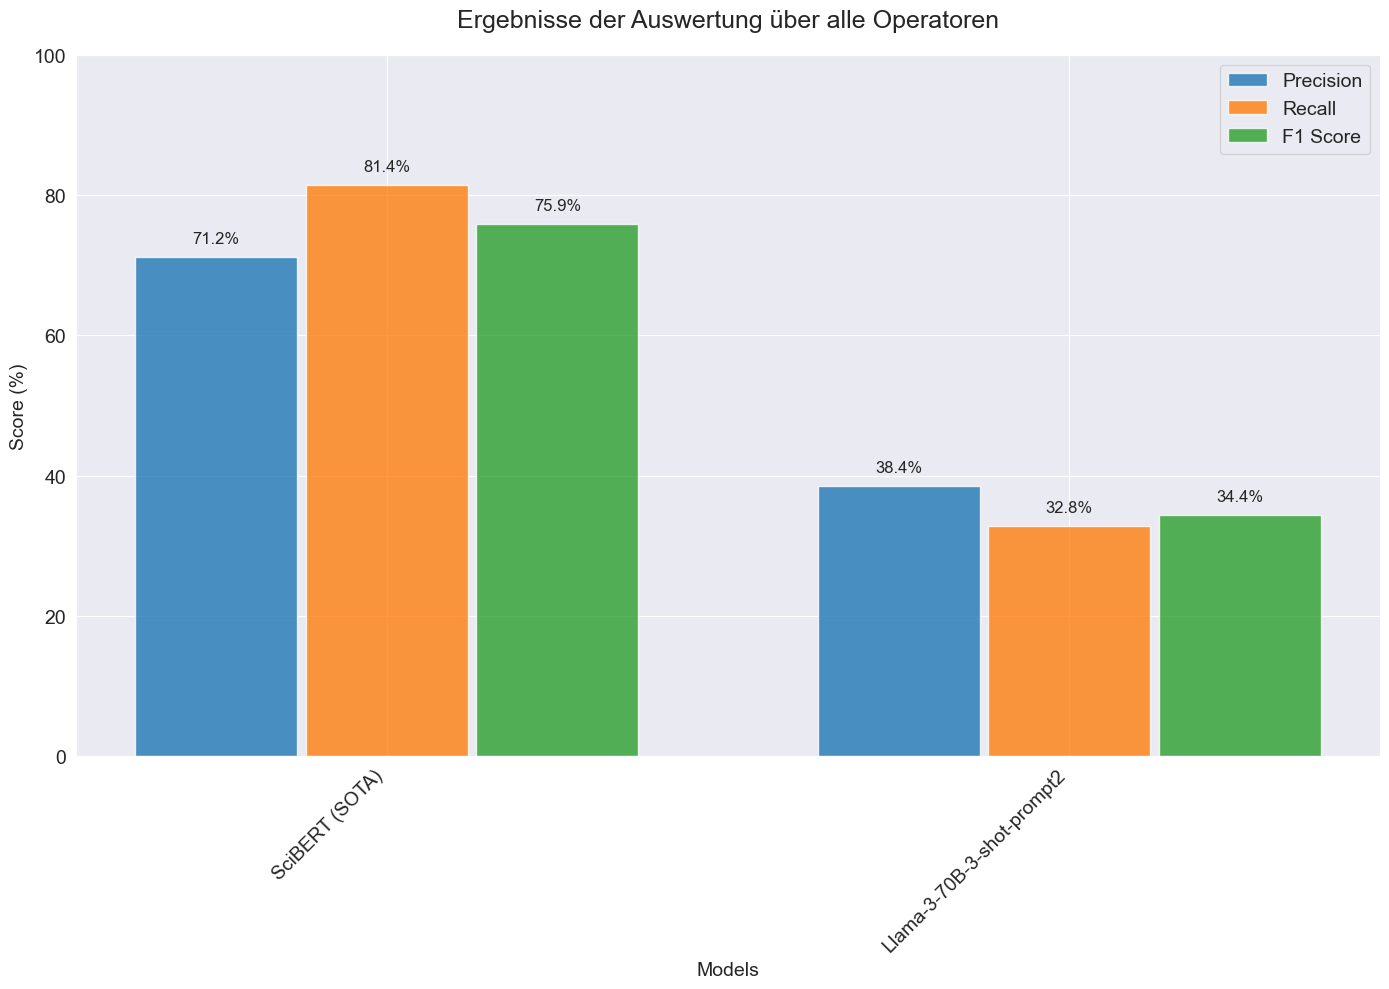

In [39]:
plot_avg_metrics(all_metrics)

In [40]:
def plot_operator_metrics(all_metrics):
    operators = ['AND', 'AND1', 'OR', 'NOT']
    metrics_to_plot = ['precision', 'recall', 'f1']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Farben für Precision, Recall, F1

    sota_metrics = {
        'SciBERT': {
            'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
            'AND1': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
            'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
            'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
        }
    }

    for i, op in enumerate(operators):
        plt.figure(figsize=(12, 8))  # Größere Figur

        model_names = ['SOTA'] + [e.replace('_p4_ep10_p1', '') for e in list(all_metrics.keys())]
        metric_values = {metric: [] for metric in metrics_to_plot}

        # SOTA-Metriken hinzufügen
        for metric in metrics_to_plot:
            metric_values[metric].append(sota_metrics['SciBERT'][op][metric])

        # Andere Modellmetriken hinzufügen
        for model, model_metrics in all_metrics.items():
            for metric in metrics_to_plot:
                metric_values[metric].append(model_metrics[op][metric])

        x = np.arange(len(model_names))
        bar_width = 0.25
        opacity = 0.8

        for j, metric in enumerate(metrics_to_plot):
            plt.bar(x + j * bar_width, metric_values[metric], bar_width,
                    alpha=opacity, label=metric.capitalize(), color=colors[j])

        plt.xlabel('Models', fontsize=14, labelpad=10)
        plt.ylabel('Score (%)', fontsize=14, labelpad=10)
        plt.title(f'Evaluation: {op}', fontsize=18, pad=20)  # Mehr Abstand nach dem Titel
        plt.xticks(x + bar_width, model_names, rotation=45, ha='right', fontsize=12)
        plt.ylim(0, 110)  # Erhöhung des y-Limits für mehr Platz oben
        plt.legend(fontsize=12, loc='upper center', ncol=3)  # Legende unter dem Plot
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Werte über den Balken anzeigen
        for j, metric in enumerate(metrics_to_plot):
            for k, v in enumerate(metric_values[metric]):
                plt.text(k + j * bar_width, v + 2, f'{v:.1f}%',
                         ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()

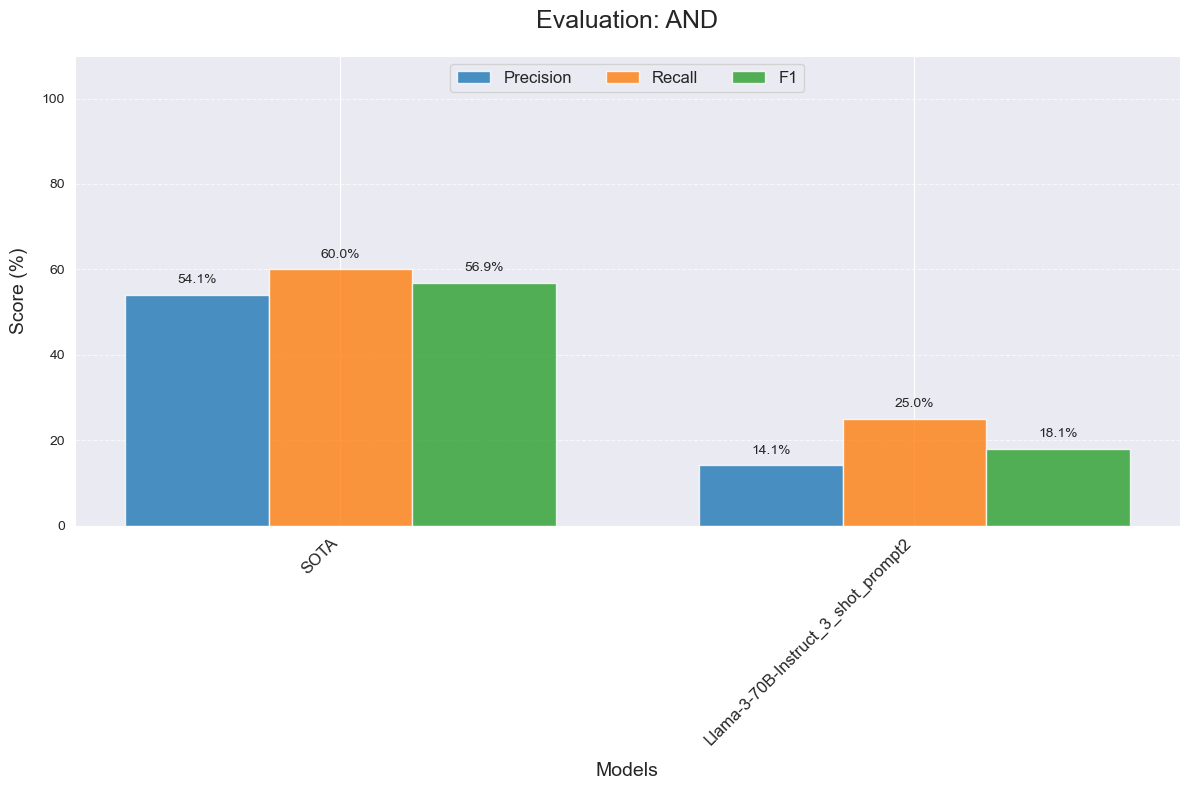

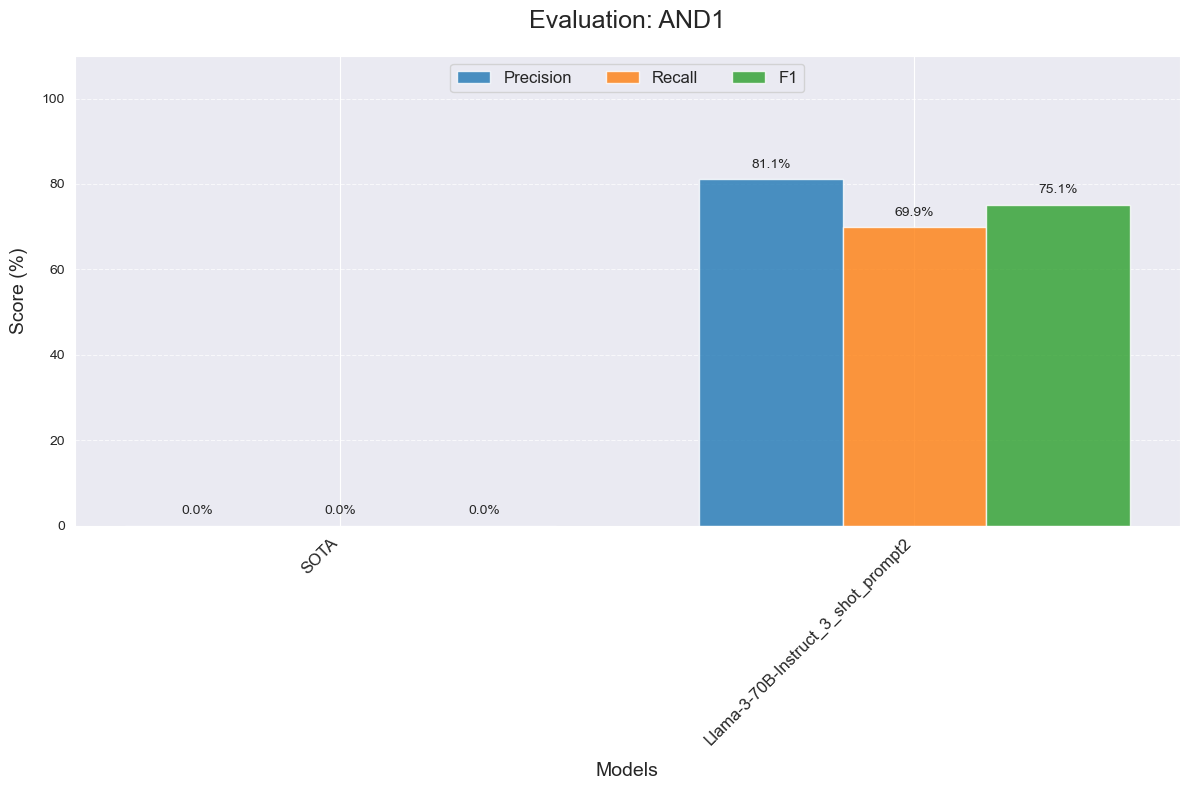

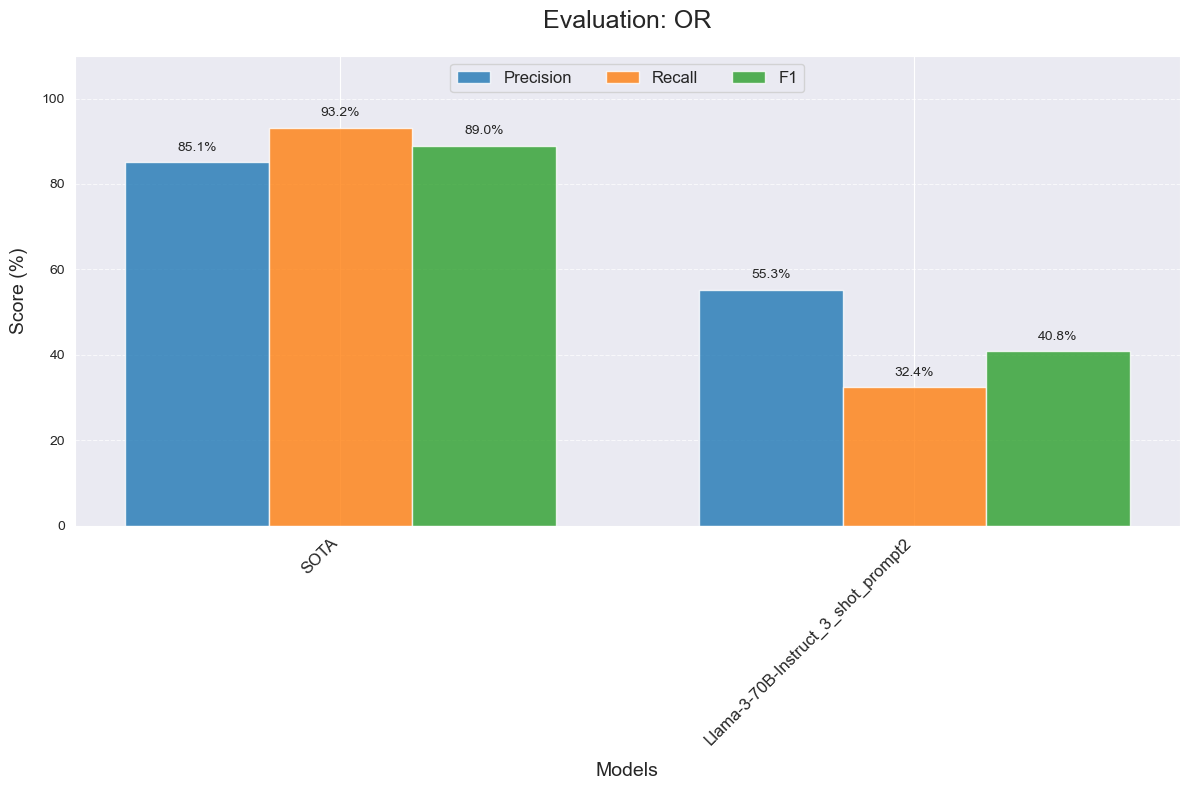

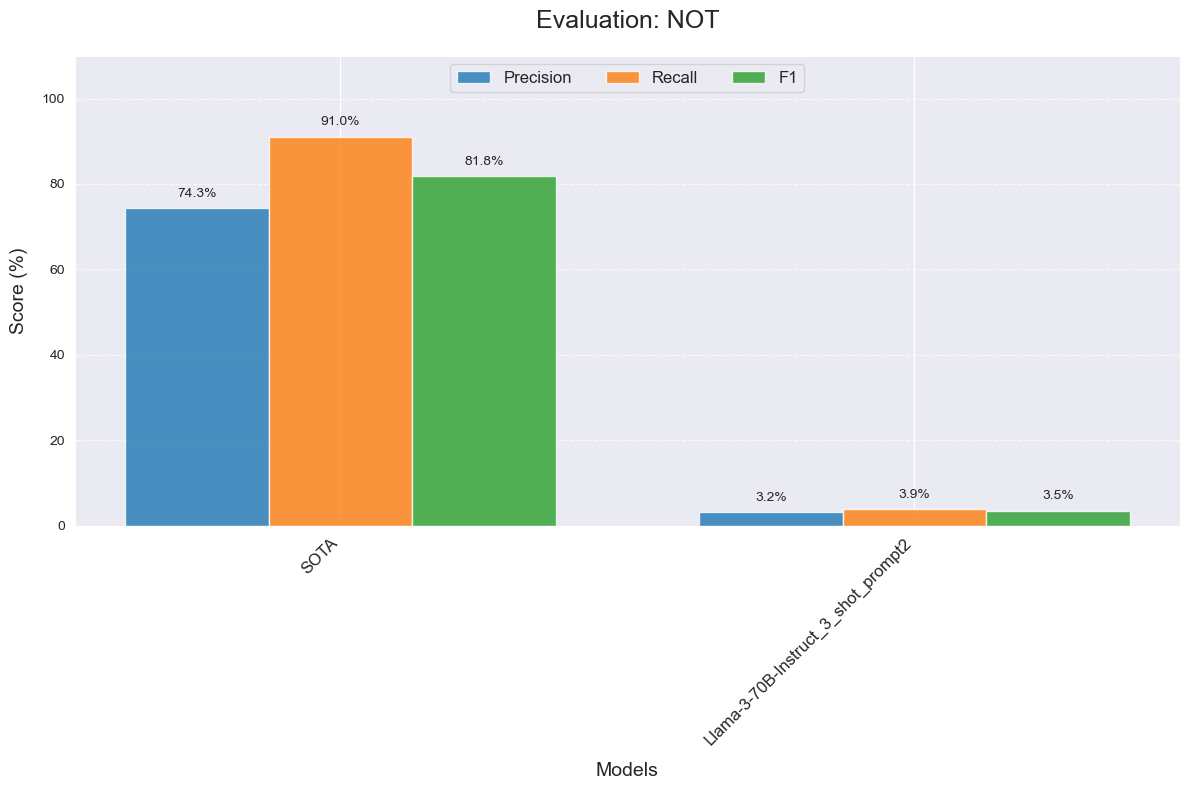

In [41]:
plot_operator_metrics(all_metrics)

In [42]:
def latex_operator_metrics_table(all_metrics):
    operators = ['AND', 'AND1', 'OR', 'NOT']
    metrics_to_plot = ['precision', 'recall', 'f1']

    sota_metrics = {
        'SciBERT': {
            'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
            'AND1': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
            'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
            'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
        }
    }

    latex_table = r"\begin{table}[ht]" + "\n"
    latex_table += r"\centering" + "\n"
    latex_table += r"\small" + "\n"
    latex_table += r"\begin{tabular}{llrrrr}" + "\n"
    latex_table += r"\toprule" + "\n"
    latex_table += r"\textbf{Model} & \textbf{Metrik} & \multicolumn{4}{c}{\textbf{Operator}} \\" + "\n"
    latex_table += r"\cmidrule(lr){3-6}" + "\n"
    latex_table += r"& & AND & AND1 & OR & NOT \\" + "\n"
    latex_table += r"\midrule" + "\n"

    model_names = ['SOTA'] + list(all_metrics.keys())

    for model in model_names:
        model_display = 'SOTA\n(SciBERT)' if model == 'SOTA' else 'Llama3 70B\n(Fine-Tuned)'
        for i, metric in enumerate(metrics_to_plot):
            metric_display = 'Precision' if metric == 'precision' else 'Recall' if metric == 'recall' else 'F1-Score'
            latex_table += f"{model_display if i == 0 else ''} & {metric_display}"
            for op in operators:
                if model == 'SOTA':
                    value = sota_metrics['SciBERT'][op][metric]
                else:
                    value = all_metrics[model][op][metric]
                latex_table += f" & {value:.1f}"
            latex_table += r" \\" + "\n"
        if model != model_names[-1]:
            latex_table += r"\midrule" + "\n"

    latex_table += r"\bottomrule" + "\n"
    latex_table += r"\end{tabular}" + "\n"
    latex_table += r"\caption{Vergleich der Operatormetriken für SOTA (SciBERT) und Llama3 70B (Fine-Tuned)}" + "\n"
    latex_table += r"\label{tab:operator_metrics}" + "\n"
    latex_table += r"\end{table}"

    return latex_table

# Beispielaufruf:
print(latex_operator_metrics_table(all_metrics))

\begin{table}[ht]
\centering
\small
\begin{tabular}{llrrrr}
\toprule
\textbf{Model} & \textbf{Metrik} & \multicolumn{4}{c}{\textbf{Operator}} \\
\cmidrule(lr){3-6}
& & AND & AND1 & OR & NOT \\
\midrule
SOTA
(SciBERT) & Precision & 54.1 & 0.0 & 85.1 & 74.3 \\
 & Recall & 60.0 & 0.0 & 93.2 & 91.0 \\
 & F1-Score & 56.9 & 0.0 & 89.0 & 81.8 \\
\midrule
Llama3 70B
(Fine-Tuned) & Precision & 14.1 & 81.1 & 55.3 & 3.2 \\
 & Recall & 25.0 & 69.9 & 32.4 & 3.9 \\
 & F1-Score & 18.1 & 75.1 & 40.8 & 3.5 \\
\bottomrule
\end{tabular}
\caption{Vergleich der Operatormetriken für SOTA (SciBERT) und Llama3 70B (Fine-Tuned)}
\label{tab:operator_metrics}
\end{table}
